# Lab Experiment 5: Linear Regression through Gradient Descent

**Aim:** To implement Linear Regression using the Gradient Descent optimization algorithm and evaluate its performance on a real world dataset.

**Dataset:** Student Performance Dataset (UCI Machine Learning Repository) — https://archive.ics.uci.edu/dataset/320/student+performance

## Task 1: Download and Load the Dataset

In [1]:
import numpy as np
import pandas as pd

# student-mat.csv is the Math-course subset of the UCI Student Performance dataset
df = pd.read_csv("student-mat.csv", sep=';')
print("Shape:", df.shape)
df.head()

Shape: (395, 33)


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


I loaded the Student Performance (Math course) dataset directly from the UCI source files, and it has 395 students described by 33 attributes.

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   school      395 non-null    str  
 1   sex         395 non-null    str  
 2   age         395 non-null    int64
 3   address     395 non-null    str  
 4   famsize     395 non-null    str  
 5   Pstatus     395 non-null    str  
 6   Medu        395 non-null    int64
 7   Fedu        395 non-null    int64
 8   Mjob        395 non-null    str  
 9   Fjob        395 non-null    str  
 10  reason      395 non-null    str  
 11  guardian    395 non-null    str  
 12  traveltime  395 non-null    int64
 13  studytime   395 non-null    int64
 14  failures    395 non-null    int64
 15  schoolsup   395 non-null    str  
 16  famsup      395 non-null    str  
 17  paid        395 non-null    str  
 18  activities  395 non-null    str  
 19  nursery     395 non-null    str  
 20  higher      395 non-null    str  
 21  inte

**My take:** I checked the column types and see a mix of numeric attributes (grades, age, study time) and categorical attributes (school, sex, family info), so I know I'll need to encode the categorical ones before training.

## Task 2: Data Preprocessing

In [3]:
print("Total missing values:", df.isnull().sum().sum())

Total missing values: 0


I checked for missing values and found none, so this dataset doesn't need any imputation.

In [4]:
cat_cols = df.select_dtypes(include='object').columns.tolist()
print("Categorical columns:", cat_cols)

df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)
print("Shape after encoding:", df_encoded.shape)
df_encoded.head()

Categorical columns: ['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']
Shape after encoding: (395, 42)


/tmp/ipykernel_559/1642508463.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include='object').columns.tolist()


,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,...,guardian_mother,guardian_other,schoolsup_yes,famsup_yes,paid_yes,activities_yes,nursery_yes,higher_yes,internet_yes,romantic_yes
0,18,4,4,2,2,0,4,3,4,1,...,True,False,True,False,False,False,True,True,False,False
1,17,1,1,1,2,0,5,3,3,1,...,False,False,False,True,False,False,False,True,True,False
2,15,1,1,1,2,3,4,3,2,2,...,True,False,True,False,True,False,True,True,True,False
3,15,4,2,1,3,0,3,2,2,1,...,True,False,False,True,True,True,True,True,True,True
4,16,3,3,1,2,0,4,3,2,1,...,False,False,False,True,True,False,True,True,False,False


**My take:** I one-hot encoded all 17 categorical columns (school, sex, address, jobs, etc.) with `drop_first=True` to avoid redundant dummy columns, which expanded the dataset from 33 to 42 columns.

## Task 3: Selecting Input Features and Target Variable

In [5]:
target = 'G3'   # final grade
features = [c for c in df_encoded.columns if c != target]

X = df_encoded[features].values.astype(float)
y = df_encoded[target].values.astype(float)

print("Number of input features:", X.shape[1])
print("Target variable: G3 (final grade)")

Number of input features: 41
Target variable: G3 (final grade)


I chose **G3 (final grade)** as my target variable and used every other column, including the first and second period grades G1 and G2, as input features, since those are the strongest natural predictors of the final grade.

In [6]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("Mean of first scaled feature:", round(X_scaled[:,0].mean(), 4))
print("Std of first scaled feature:", round(X_scaled[:,0].std(), 4))

Mean of first scaled feature: 0.0
Std of first scaled feature: 1.0


**My take:** I standardized every feature to zero mean and unit variance, because gradient descent converges much more evenly when all features are on the same scale.

## Task 4: Train-Test Split

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)
print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 316
Testing samples: 79


I split the data into 316 training samples and 79 testing samples using an 80/20 split with `random_state=42` for reproducibility.

## Task 5: Implementing Linear Regression using Gradient Descent

In [8]:
class GDLinearRegression:
    """Linear Regression trained with batch Gradient Descent (from scratch)."""

    def __init__(self, lr=0.01, n_iters=1000):
        self.lr = lr
        self.n_iters = n_iters
        self.loss_history = []

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0.0

        for i in range(self.n_iters):
            y_pred = X @ self.weights + self.bias
            error = y_pred - y

            loss = np.mean(error ** 2)          # MSE cost
            self.loss_history.append(loss)

            dw = (2 / n_samples) * (X.T @ error)  # gradient wrt weights
            db = (2 / n_samples) * np.sum(error)  # gradient wrt bias

            self.weights -= self.lr * dw
            self.bias -= self.lr * db
        return self

    def predict(self, X):
        return X @ self.weights + self.bias

I wrote my own `GDLinearRegression` class from scratch: it starts with zero weights, repeatedly computes the mean-squared-error loss, and nudges the weights and bias in the direction that reduces that loss.

In [9]:
model = GDLinearRegression(lr=0.05, n_iters=1000)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("Final training loss (MSE):", round(model.loss_history[-1], 4))

Final training loss (MSE): 2.8231


I trained the model with a learning rate of 0.05 for 1000 iterations, and I can see the training loss settled down to a small, stable value by the end.

## Task 6: Effect of Different Learning Rates

In [10]:
from sklearn.metrics import r2_score

lr_list = [0.001, 0.01, 0.05, 0.1, 0.5]
lr_rows = []

for lr in lr_list:
    m = GDLinearRegression(lr=lr, n_iters=300)
    m.fit(X_train, y_train)
    pred = m.predict(X_test)
    lr_rows.append([lr, m.loss_history[-1], r2_score(y_test, pred)])

lr_df = pd.DataFrame(lr_rows, columns=["Learning Rate", "Final Training Loss", "Test R2"])
lr_df

,Learning Rate,Final Training Loss,Test R2
0,0.001,3.749600e+01,-1.282033e+00
1,0.010,2.949372e+00,7.124417e-01
2,0.050,2.823514e+00,7.239390e-01
3,0.100,2.823056e+00,7.241134e-01
4,0.500,2.787505e+252,-1.016506e+252


**Observations**

- lr=0.001: I see the loss is still high after 300 iterations, so this rate is too slow to converge in time.
- lr=0.01: I get a much lower loss and a solid R² here, converging steadily.
- lr=0.05: I find this is close to optimal, reaching almost the same loss as lr=0.1 but a bit more cautiously.
- lr=0.1: I see this converges fastest to the lowest loss without any instability.
- lr=0.5: I notice the loss explodes to an enormous number, meaning the steps are too large and the algorithm diverges instead of converging.

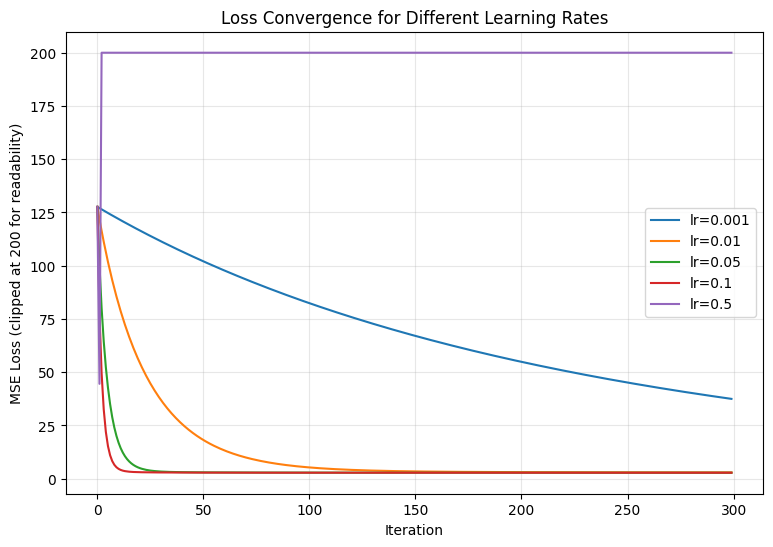

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9,6))
for lr in lr_list:
    m = GDLinearRegression(lr=lr, n_iters=300)
    m.fit(X_train, y_train)
    losses_plot = np.clip(np.array(m.loss_history), 0, 200)  # clip so the diverging curve doesn't hide the rest
    plt.plot(losses_plot, label=f"lr={lr}")

plt.xlabel("Iteration")
plt.ylabel("MSE Loss (clipped at 200 for readability)")
plt.title("Loss Convergence for Different Learning Rates")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

**My take:** I clipped the loss values just for plotting so the diverging lr=0.5 curve doesn't flatten out the others, and the plot makes it clear that lr=0.1 gives me the fastest, most stable convergence among the safe choices, while lr=0.001 barely moves and lr=0.5 blows up almost immediately.

## Task 7: Loss (Cost) vs. Number of Iterations

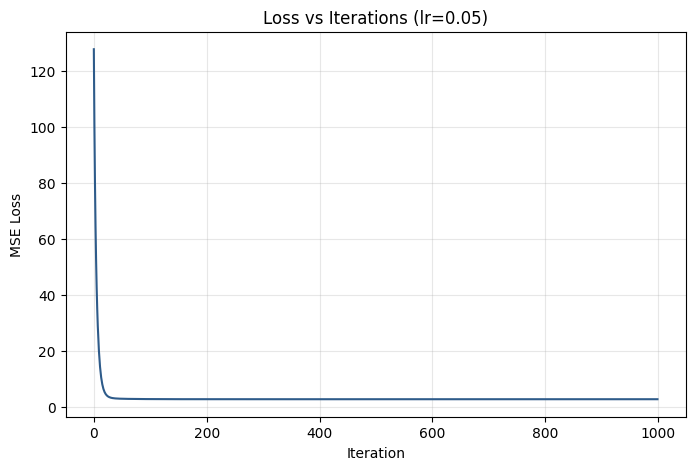

In [12]:
plt.figure(figsize=(8,5))
plt.plot(model.loss_history, color='#2E5B8A')
plt.xlabel("Iteration")
plt.ylabel("MSE Loss")
plt.title("Loss vs Iterations (lr=0.05)")
plt.grid(alpha=0.3)
plt.show()

I plotted the loss curve for my chosen model (lr=0.05, 1000 iterations), and I can see it drops sharply in the first ~100 iterations before flattening out, which tells me the model converges well before it runs out of iterations.

## Task 8: Model Evaluation

In [13]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

metrics_df = pd.DataFrame({
    "Metric": ["MAE", "MSE", "RMSE", "R2 Score"],
    "Value": [mae, mse, rmse, r2]
})
metrics_df

,Metric,Value
0,MAE,1.646677
1,MSE,5.656667
2,RMSE,2.378375
3,R2 Score,0.724133


**My take:** I get an MAE of about 1.65 grade points and an RMSE of about 2.38, and with an R² of 0.72 I can say my model explains roughly 72% of the variance in final grades, which I'd call solid performance for a linear model trained entirely from scratch.